<a href="https://colab.research.google.com/github/RonakkudalAI/Practical-Machine-Learning/blob/main/Naive_Bayes(Day_8).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [82]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [83]:
df = pd.read_csv("/content/Day5.csv")
df

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [84]:
df.describe()

,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


In [85]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [87]:
df.isnull().sum()

,0
User ID,0
Gender,0
Age,0
EstimatedSalary,0
Purchased,0


In [88]:
df = df.drop("User ID", axis = 1)

In [89]:
df

,Gender,Age,EstimatedSalary,Purchased
0,Male,19,19000,0
1,Male,35,20000,0
2,Female,26,43000,0
3,Female,27,57000,0
4,Male,19,76000,0
...,...,...,...,...
395,Female,46,41000,1
396,Male,51,23000,1
397,Female,50,20000,1
398,Male,36,33000,0


In [90]:
from sklearn.preprocessing import OneHotEncoder


ohe = OneHotEncoder(sparse_output=False)

encoded = ohe.fit_transform(df[['Gender']])   # pass as 2D

encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(['Gender']))

# Drop original column and join new ones
df = df.drop('Gender', axis=1)
df = pd.concat([df, encoded_df], axis=1)


In [91]:
df

,Age,EstimatedSalary,Purchased,Gender_Female,Gender_Male
0,19,19000,0,0.0,1.0
1,35,20000,0,0.0,1.0
2,26,43000,0,1.0,0.0
3,27,57000,0,1.0,0.0
4,19,76000,0,0.0,1.0
...,...,...,...,...,...
395,46,41000,1,1.0,0.0
396,51,23000,1,0.0,1.0
397,50,20000,1,1.0,0.0
398,36,33000,0,0.0,1.0


<Axes: xlabel='Purchased', ylabel='count'>

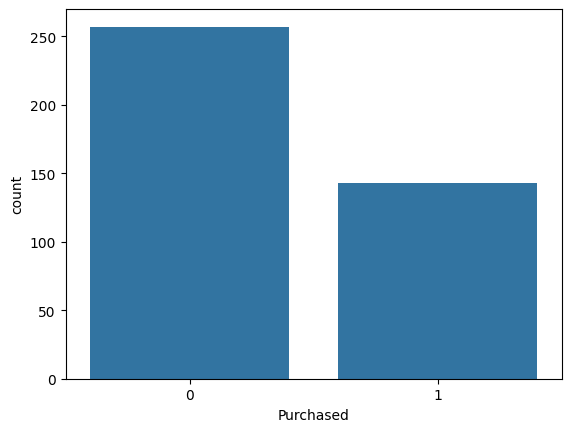

In [92]:
sns.countplot(x='Purchased', data=df)

<Axes: xlabel='Age', ylabel='Count'>

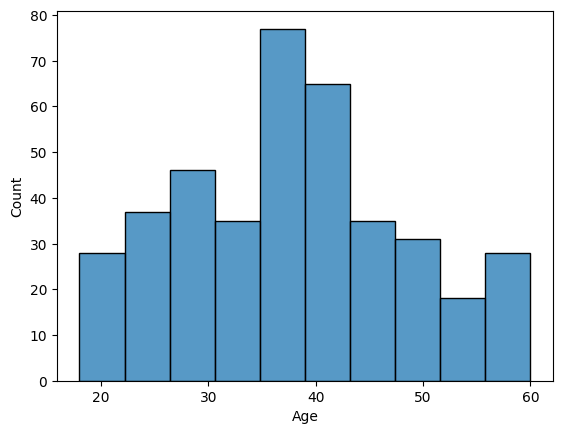

In [93]:
sns.histplot(df['Age'])

<Axes: xlabel='Gender_Male', ylabel='count'>

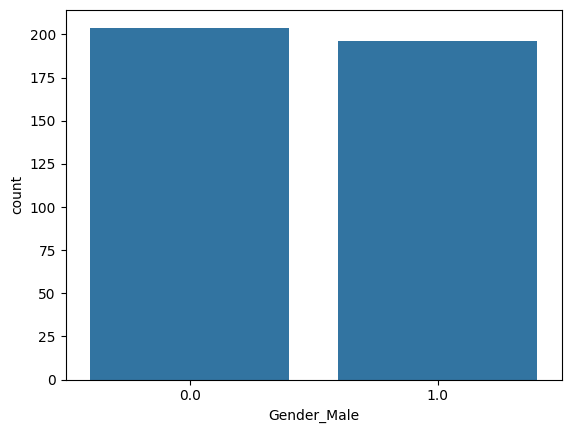

In [94]:
sns.countplot(x = 'Gender_Male',data = df)

<Axes: xlabel='Gender_Female', ylabel='count'>

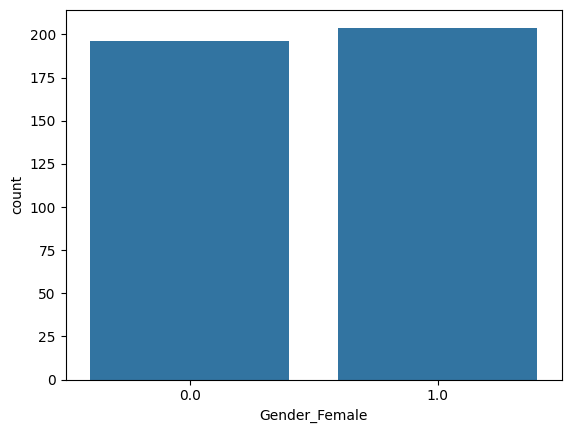

In [95]:
sns.countplot(x = 'Gender_Female',data = df)

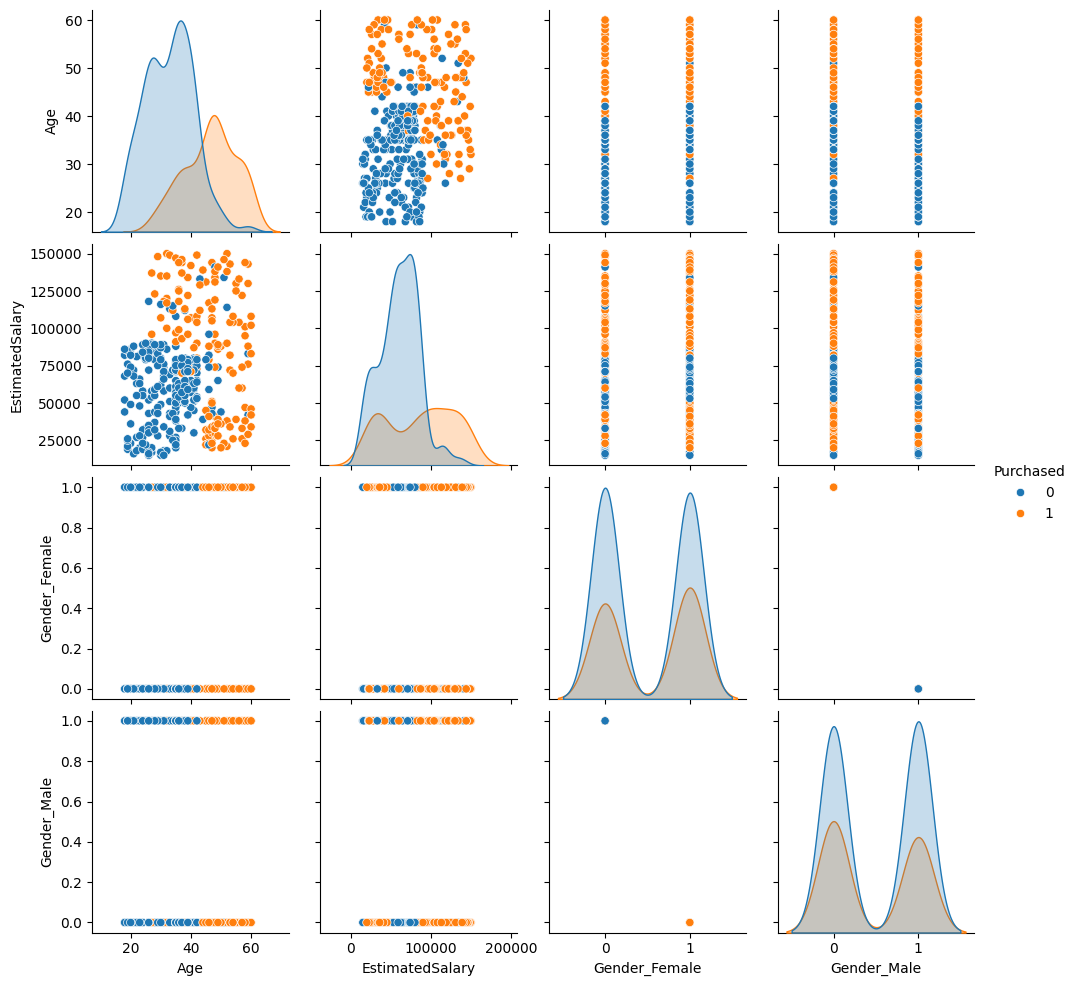

In [96]:
sns.pairplot(df,hue ="Purchased")

<Axes: xlabel='Age'>

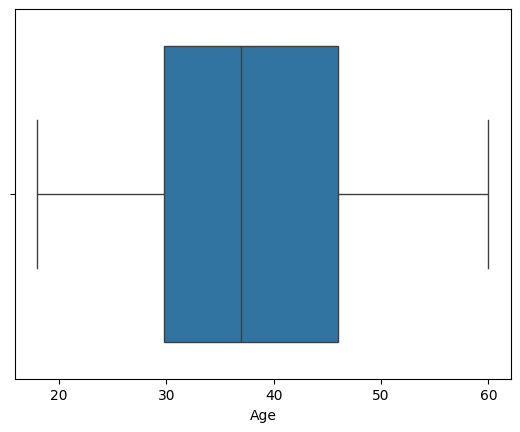

In [97]:
sns.boxplot(x=df['Age'])

Correlation


In [98]:
df.corr

<bound method DataFrame.corr of      Age  EstimatedSalary  Purchased  Gender_Female  Gender_Male
0     19            19000          0            0.0          1.0
1     35            20000          0            0.0          1.0
2     26            43000          0            1.0          0.0
3     27            57000          0            1.0          0.0
4     19            76000          0            0.0          1.0
..   ...              ...        ...            ...          ...
395   46            41000          1            1.0          0.0
396   51            23000          1            0.0          1.0
397   50            20000          1            1.0          0.0
398   36            33000          0            0.0          1.0
399   49            36000          1            1.0          0.0

[400 rows x 5 columns]>

<Axes: >

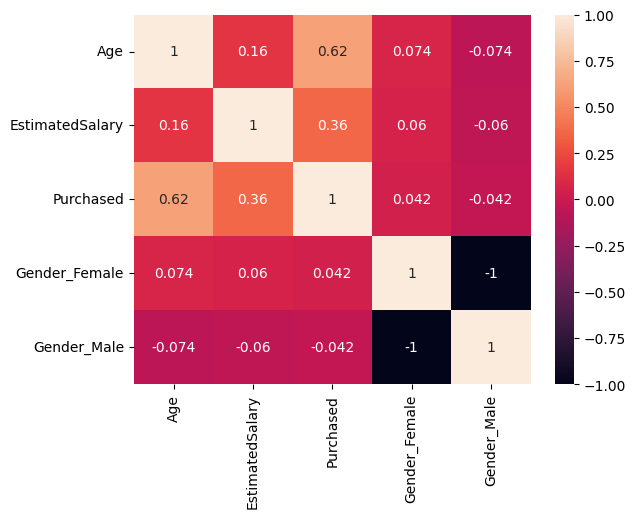

In [99]:
sns.heatmap(df.corr(),annot=True)

In [100]:
X = df.drop('Purchased',axis=1)
y = df['Purchased']

In [101]:
from sklearn.model_selection import train_test_split
X_train , X_test, y_train , y_test= train_test_split(X,y,train_size = 0.8,random_state = 42 )

In [123]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train_Scaled = sc.fit_transform(X_train)
X_test_Scaled = sc.transform(X_test)

In [132]:
from sklearn.linear_model import LogisticRegression

modelLr = LogisticRegression()
modelLr.fit(X_train_Scaled,y_train)

LogisticRegression()

In [138]:
y_pred_LR = modelLr.predict(X_test_Scaled)

In [139]:
y_pred_LR

array([0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0,
       0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0])

In [140]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred_LR))

Accuracy: 0.8875


In [128]:
from sklearn.neighbors import KNeighborsClassifier
modelKnn= KNeighborsClassifier(n_neighbors=5)
modelKnn.fit(X_train_Scaled,y_train)

KNeighborsClassifier()

In [142]:
y_pred_knn = modelKnn.predict(X_test_Scaled)

In [143]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred_knn))

Accuracy: 0.925


In [145]:
from sklearn.naive_bayes import GaussianNB
model_naive= GaussianNB()
model_naive.fit(X_train_Scaled,y_train)

GaussianNB()

In [146]:
y_pred_naive= model_naive.predict(X_test_Scaled)

In [147]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred_naive))

Accuracy: 0.925
